In [64]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from datetime import datetime
from sklearn.cluster import DBSCAN


In [65]:
symbols = pd.read_csv("symbols.csv")['Symbol'].tolist()
netAssets = pd.read_csv("net_assets.csv")
closes = pd.read_csv("closes.csv", index_col=0)

netAssets['Inception Date'] = pd.to_datetime(netAssets['Inception Date'])
netAssets = netAssets[netAssets['Inception Date'] <= pd.Timestamp('2011-01-01')]
goodSymbols = netAssets['Symbol'].tolist()
goodCloses = closes[goodSymbols]
goodCloses = goodCloses.loc['2010-09-22':]

**I need to find clusters for hyperparameter tuning for like ETFs. If I do it on a per ETF instance, it becomes way to susceptible to overfitting, but if I do it on a generalized basis, it doesn't allow for good convergence. I am choosing DBSCAN because it can handle noise and I don't know how many clusters there will be.**

In [66]:
returns = goodCloses.pct_change().dropna()
corr = returns.corr()
dist = np.sqrt(2 * (1 - corr))



In [67]:
#DBSCAN Clustering
DBmodel = DBSCAN(eps=0.5, min_samples=2, metric='precomputed')
DBclusters = DBmodel.fit_predict(dist)

uniqueClusters = set(DBclusters)
for cluster in uniqueClusters:
    if cluster == -1:
        print("No fit:")
    else:
        print(f"Cluster {cluster + 1}:")
    clusterSymbols = [goodSymbols[j] for j in range(len(goodSymbols)) if DBclusters[j] == cluster]
    print(f"{', '.join(clusterSymbols)}")


Cluster 1:
VONG, VOO, VOOG, TQQQ, SCHG, SCHF, SCHX, SCHB, VT, ACWI, MGK, VEA, SPDW, VEU, VYM, VIG, EFV, VWO, VGK, VV, VTV, VO, VBR, VUG, VGT, VB, ITOT, RSP, EEM, VXF, EFA, IWR, SOXX, VTI, SPYG, SPYV, IUSG, IJR, IWF, IWM, IVE, IWD, IVW, IJH, IVV, IWB, QQQ, XLK, XLI, XLF, DIA, MDY, SPY
Cluster 2:
VCIT, VGIT, BND, BIV, AGG, LQD, TLT, IEF
Cluster 3:
IAU, GLD
No fit:
VCSH, VGSH, MUB, BIL, BSV, MBB, GDX, SLV, VNQ, XLV, XLE


**I like that the DBSCAN algorithm gave me two strong clusters. The third is ehh whatever, but interesting in the fact that the ETFs in cluster 3 don't cluster well with those in 'Noise' because it is gold based. With that, I'm going to manually make the three clusters as this:

Cluster 1: [VONG, VOO, VOOG, TQQQ, SCHG, SCHF, SCHX, SCHB, VT, ACWI, MGK, DFAC, VEA, SPDW, VEU, VYM, VIG, EFV, VWO, VGK, VV, VTV, VO, VBR, VUG, VGT, VB, ITOT, RSP, EEM, VXF, EFA, IWR, SOXX, VTI, SPYG, SPYV, IUSG, IJR, IWF, IWM, IVE, IWD, IVW, IJH, IVV, IWB, QQQ, XLK, XLI, XLF, DIA, MDY, SPY, **XLV**, **XLE**]

Cluster 2: [VCIT, VGIT, VCSH, VGSH, BND, BSV, BIV, MBB, AGG, LQD, TLT, IEF, **MUB**, **BIL**, ]

Cluster 3: [IAU, GLD, **GDX**, **SLV**]


Note MUB and BIL made it into cluster 2 because this is entirely comprised of fixed income ETFs

GDX and SLV made it into cluster 3 becaus these comprise of Gold and Silver ETFs

XLV and XLE made it into cluster 1 because they don't belong in 1 or 2, but additonally, other subsector ETFs are in cluster 1


In [68]:
def stochastic(df, n=14):
    low = df['Close'].rolling(window=n).min()
    high = df['Close'].rolling(window=n).max()

    dnom = high - low
    dnom = dnom.replace(0, 1e-9)

    k = (df['Close'] - low) / dnom * 100
    d = k.rolling(window=3).mean()

    return k, d

def calcRegimeFilter(df):
    df = df.copy()

    df['Bull Regime'] = df['Close'] > df['SMA_200']
    df['Bear Regime'] = df['Close'] < df['SMA_200']

    df['High Volatility Regime'] = df['vol_20'] > df['vol_50']
    df['Low Volatility Regime'] = df['vol_20'] < df['vol_50']

    df['Regime'] = np.select(
        [
            (df['Bull Regime'] & df['Low Volatility Regime']),
            (df['Bull Regime'] & df['High Volatility Regime']),
            (df['Bear Regime'] & df['Low Volatility Regime']),
            (df['Bear Regime'] & df['High Volatility Regime'])
        ],
        [
            'Bull-Low Vol',
            'Bull-High Vol',
            'Bear-Low Vol',
            'Bear-High Vol'
        ],
        default='No Regime'
    )

    

    return df

def getTarget(df):
    df = df.copy()
    df['Target'] = np.where(df['Returns'].shift(-1) > 0, 1, 0)
    return df

def getTechnicalData(closes):
    df = pd.DataFrame()
    df['Close'] = closes
    df['Returns'] = closes.pct_change()
    df['SMA_20'] = closes.rolling(window=20).mean()
    df['SMA_50'] = closes.rolling(window=50).mean()
    df['SMA_200'] = closes.rolling(window=200).mean()

    df['vol_20'] = closes.rolling(window=20).std()
    df['vol_50'] = closes.rolling(window=50).std()

    df = calcRegimeFilter(df)
    df['K'], df['D'] = stochastic(df)
    df['K_minus_D'] = df['K'] - df['D']
    df['K_cross_D'] = np.where((df['K'] > df['D']) & (df['K'].shift(1) <= df['D'].shift(1)), 1, 0)
    df['dist_ma'] = (df['Close'] - df['SMA_200']) / df['SMA_200']
    df['vol_ratio'] = df['vol_20'] / df['vol_50']
    df['Target'] = np.where(df['Returns'].shift(-1) > 0, 1, 0)

    return df.dropna()






In [69]:
#Test for the big loop

spyTest = goodCloses['SPY']
technicalSPY = getTechnicalData(spyTest)
dummyVars = pd.get_dummies(technicalSPY['Regime']).astype(int)
dummyVars['Standardized Regime'] = np.where(
    technicalSPY['Regime'] == 'Bull-Low Vol', 0, np.where(
        technicalSPY['Regime'] == 'Bull-High Vol', 1, np.where(
            technicalSPY['Regime'] == 'Bear-Low Vol', 2, np.where(
                technicalSPY['Regime'] == 'Bear-High Vol', 3, 4
            )
        )
    )
)
technicalSPY = pd.concat([technicalSPY, dummyVars['Standardized Regime']], axis=1)
technicalSPY




,Close,Returns,SMA_20,SMA_50,SMA_200,vol_20,vol_50,Bull Regime,Bear Regime,High Volatility Regime,Low Volatility Regime,Regime,K,D,K_minus_D,K_cross_D,dist_ma,vol_ratio,Target,Standardized Regime
Date,,,,,,,,,,,,,,,,,,,,
2011-07-07,135.360001,0.010375,129.681000,131.956599,127.282450,2.698007,3.024643,True,False,False,True,Bull-Low Vol,100.000000,99.484292,0.515708,0,0.063462,0.892008,0,0
2011-07-08,134.399994,-0.007092,129.931000,131.931199,127.387350,2.895055,2.998038,True,False,False,True,Bull-Low Vol,88.771855,96.257285,-7.485430,0,0.055050,0.965650,0,0
2011-07-11,131.970001,-0.018080,130.149500,131.848399,127.484700,2.874705,2.936817,True,False,False,True,Bull-Low Vol,60.350898,83.040918,-22.690019,0,0.035183,0.978851,0,0
2011-07-12,131.399994,-0.004319,130.334500,131.747799,127.567600,2.827439,2.861867,True,False,False,True,Bull-Low Vol,53.684149,67.602301,-13.918152,0,0.030042,0.987970,1,0
2011-07-13,131.839996,0.003349,130.460499,131.660199,127.655450,2.835987,2.788270,True,False,True,False,Bull-High Vol,58.830374,57.621807,1.208567,1,0.032780,1.017114,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-20,708.719971,-0.002000,669.624500,675.613400,666.918199,24.233857,18.108583,True,False,True,False,Bull-High Vol,97.625344,99.208448,-1.583104,0,0.062679,1.338252,0,1
2026-04-21,704.080017,-0.006547,672.059500,675.882600,667.311899,25.156362,18.433358,True,False,True,False,Bull-High Vol,88.961758,95.529034,-6.567276,0,0.055099,1.364719,1,1
2026-04-22,711.210022,0.010127,674.961002,676.227800,667.764549,26.189554,18.933440,True,False,True,False,Bull-High Vol,100.000000,95.529034,4.470966,1,0.065061,1.383243,0,1


In [70]:
goodCloses

,VONG,VOO,VOOG,TQQQ,SCHG,VCIT,VGIT,VCSH,VGSH,SCHF,...,IWB,QQQ,XLK,XLI,XLF,XLV,XLE,DIA,MDY,SPY
Date,,,,,,,,,,,,,,,,,,,,,
2010-09-22,12.952500,104.160004,8.745000,0.278620,3.315000,81.510002,63.560001,78.370003,60.849998,12.960000,...,62.910000,48.689999,11.355000,31.059999,11.787165,30.410000,27.219999,107.400002,142.070007,113.419998
2010-09-23,12.987500,103.300003,8.725000,0.277786,3.296250,81.510002,63.689999,78.250000,60.830002,12.820000,...,62.119999,48.669998,11.340000,30.600000,11.559708,30.250000,27.049999,106.669998,141.080002,112.500000
2010-09-24,13.147500,104.839996,8.890000,0.293516,3.370000,81.199997,63.439999,78.330002,60.740002,13.155000,...,63.389999,49.660000,11.560000,31.440001,11.868400,30.660000,27.635000,108.570000,144.419998,114.820000
2010-09-27,13.187500,104.339996,8.865000,0.290156,3.355000,81.599998,63.680000,78.389999,60.860001,13.105000,...,63.150002,49.389999,11.565000,31.240000,11.738424,30.430000,27.530001,108.190002,144.419998,114.269997
2010-09-28,13.187500,105.019997,8.896667,0.290885,3.375000,81.949997,63.930000,78.430000,60.830002,13.195000,...,63.389999,49.369999,11.580000,31.410000,11.762794,30.680000,27.725000,108.559998,145.350006,114.669998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-20,122.169998,651.539978,76.743332,58.080002,32.540001,83.500000,59.720001,79.500000,58.570000,26.760000,...,388.519989,646.789978,154.559998,173.899994,52.630001,147.419998,55.070000,494.329987,669.580017,708.719971
2026-04-21,121.279999,647.250000,76.250000,57.400002,32.330002,83.220001,59.520000,79.370003,58.500000,26.180000,...,385.880005,644.330017,154.690002,171.440002,52.299999,145.919998,55.869999,491.359985,665.619995,704.080017
2026-04-22,123.209999,653.900024,77.599998,60.209999,32.849998,83.309998,59.560001,79.419998,58.500000,26.400000,...,389.660004,655.109985,158.089996,171.039993,52.209999,146.380005,56.540001,494.760010,663.090027,711.210022


In [71]:
technicalData = {}

for symbol in goodSymbols:
    technicalDF = getTechnicalData(goodCloses[symbol])
    dummyVars = pd.get_dummies(technicalDF['Regime']).astype(int)
    dummyVars['Standardized Regime'] = np.where(
        technicalSPY['Regime'] == 'Bull-Low Vol', 0, np.where(
            technicalSPY['Regime'] == 'Bull-High Vol', 1, np.where(
                technicalSPY['Regime'] == 'Bear-Low Vol', 2, np.where(
                    technicalSPY['Regime'] == 'Bear-High Vol', 3, 4
                    )
                )
            )
    )
    technicalDF = pd.concat([technicalDF, dummyVars['Standardized Regime']], axis=1)
    technicalData[symbol] = technicalDF




In [72]:
clusterOne = ['VONG', 'VOO', 'VOOG', 'TQQQ', 'SCHG', 'SCHF', 'SCHX', 'SCHB', 'VT', 'ACWI', 'MGK', 'DFAC', 'VEA', 'SPDW', 'VEU', 'VYM', 'VIG', 'EFV', 'VWO', 'VGK', 'VV', 'VTV', 'VO', 'VBR', 'VUG', 'VGT', 'VB', 'ITOT', 'RSP', 'EEM', 'VXF', 'EFA', 'IWR', 'SOXX', 'VTI', 'SPYG', 'SPYV', 'IUSG', 'IJR', 'IWF', 'IWM', 'IVE', 'IWD', 'IVW', 'IJH', 'IVV', 'IWB', 'QQQ', 'XLK', 'XLI', 'XLF', 'DIA', 'MDY', 'SPY', 'XLV', 'XLE']
clusterTwo = ['VCIT', 'VGIT', 'VCSH', 'VGSH', 'BND', 'BSV', 'BIV', 'MBB', 'AGG', 'LQD', 'TLT', 'IEF', 'MUB', 'BIL']
clusterThree = ['IAU', 'GLD', 'GDX', 'SLV']

In [73]:
trainedModels = {}
logisticRegressionFeatures = [] 
features = ['K', 'D', 'K_minus_D', 'K_cross_D', 'dist_ma', 'vol_ratio', 'Standardized Regime'] 

XTrainDict = {}
XTestDict = {}
YTrainDict = {}
YTestDict = {}


for symbol in goodSymbols:
    df = technicalData[symbol]
    X = df[features]
    y = df['Target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    XTrainDict[symbol] = X_train_scaled
    XTestDict[symbol] = X_test_scaled
    YTrainDict[symbol] = y_train
    YTestDict[symbol] = y_test

    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)

    trainedModels[symbol] = model

    print(f'Train Accuracy for {symbol}: {model.score(X_train_scaled, y_train):.4f},  Test Accuracy for {symbol}: {model.score(X_test_scaled, y_test):.4f}')
    



Train Accuracy for VONG: 0.5559,  Test Accuracy for VONG: 0.5758
Train Accuracy for VOO: 0.5401,  Test Accuracy for VOO: 0.5544
Train Accuracy for VOOG: 0.5566,  Test Accuracy for VOOG: 0.5933
Train Accuracy for TQQQ: 0.5549,  Test Accuracy for TQQQ: 0.5826
Train Accuracy for SCHG: 0.5459,  Test Accuracy for SCHG: 0.5758
Train Accuracy for VCIT: 0.5173,  Test Accuracy for VCIT: 0.5101
Train Accuracy for VGIT: 0.5328,  Test Accuracy for VGIT: 0.4832
Train Accuracy for VCSH: 0.5297,  Test Accuracy for VCSH: 0.5020
Train Accuracy for VGSH: 0.5882,  Test Accuracy for VGSH: 0.5248
Train Accuracy for SCHF: 0.5203,  Test Accuracy for SCHF: 0.5342
Train Accuracy for SCHX: 0.5381,  Test Accuracy for SCHX: 0.5530
Train Accuracy for SCHB: 0.5364,  Test Accuracy for SCHB: 0.5490
Train Accuracy for VT: 0.5358,  Test Accuracy for VT: 0.5530
Train Accuracy for ACWI: 0.5338,  Test Accuracy for ACWI: 0.5517
Train Accuracy for MGK: 0.5469,  Test Accuracy for MGK: 0.5758
Train Accuracy for MUB: 0.5462,  

In [74]:
def getSharpeRatio(returns, risk_free_rate=0.0,periods_per_year=252):
    returns = pd.Series(returns).dropna()
    if len(returns) == 0:

        return np.nan
    excess_returns = returns - (risk_free_rate / periods_per_year)
    volatility = excess_returns.std(ddof=1)
    if volatility == 0:
        return np.nan
    
    annualized_excess_return = excess_returns.mean() * periods_per_year
    annualized_volatility = volatility * np.sqrt(periods_per_year)

    return annualized_excess_return / annualized_volatility

In [75]:
probabilities = {}
for symbol in goodSymbols:
    probabilities[symbol] = trainedModels[symbol].predict_proba(XTestDict[symbol])[:, 1]

probabilities = pd.DataFrame(probabilities)
probabilities.set_index(goodCloses.index[-745:])

signaledTrades = probabilities.where((probabilities > 0.55) | (probabilities < 0.45))

longTrades = signaledTrades.where(signaledTrades > 0.5)
longTrades.index = goodCloses.index[-745:]
longTrades = longTrades[:-1]

shortTrades = signaledTrades.where(signaledTrades < 0.5)
shortTrades.index = goodCloses.index[-745:]
shortTrades = shortTrades[:-1]

returns = closes.pct_change().shift(-1)
returns = returns.loc[shortTrades.index[0]:]
shortReturns = -1 * returns.where(shortTrades > 0)
longReturns = returns.where(longTrades > 0)
combinedReturns = longReturns.fillna(0) + shortReturns.fillna(0)


activeTrades = (combinedReturns != 0).sum(axis=1)

dailyReturns = combinedReturns.sum(axis=1) / activeTrades
dailyReturns = dailyReturns.fillna(0)

sharpeRatio = getSharpeRatio(dailyReturns.values)
sharpeRatio


np.float64(1.3520378812111662)

In [76]:
sp500 = pd.read_csv('S&P500.csv')
sp500 = sp500.set_index('Date')
sp500Return = sp500.pct_change().dropna()


spWealthIndex = (sp500Return['^GSPC']+1).cumprod()
spWealthIndex


Date
2023-05-08    1.000452
2023-05-09    0.995871
2023-05-10    1.000336
2023-05-11    0.998639
2023-05-12    0.997058
                ...   
2026-04-17    1.722831
2026-04-20    1.718740
2026-04-21    1.707829
2026-04-22    1.725694
2026-04-23    1.718561
Name: ^GSPC, Length: 743, dtype: float64

In [77]:
spSharpeRatio = getSharpeRatio(sp500Return['^GSPC'], periods_per_year=252)
spSharpeRatio


np.float64(1.3057488186929165)

<Axes: xlabel='Date'>

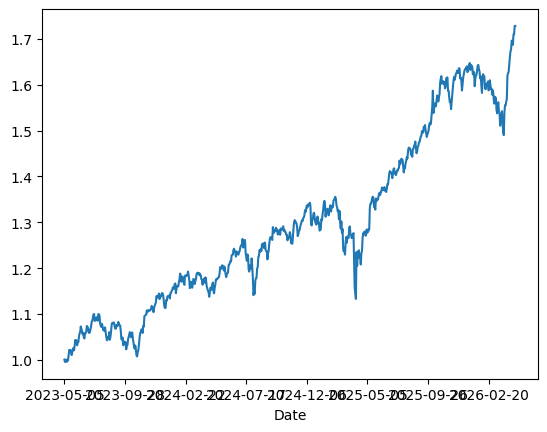

In [78]:
wealthIndex = (dailyReturns+1).cumprod()
wealthIndex.plot()

In [81]:
print(f'''This strategy yielded a {100*(wealthIndex.iloc[-1] - wealthIndex.iloc[0]/wealthIndex.iloc[0])}% return\n
      the S&P 500 had yieled a {100*(spWealthIndex.iloc[-1] - spWealthIndex.iloc[0]/spWealthIndex.iloc[0])}% return''')

This strategy yielded a 72.78881339872858% return

      the S&P 500 had yieled a 71.85614753324268% return
